# Deep Learning Vision: CNN Flood Detection from NASA Imagery
This robust notebook architects a Convolutional Neural Network (CNN) specifically tuned to parse satellite imagery directly, classifying regions visually as `Flooded` or `Safe` based on topological water pixel displacement.


In [11]:

# Auto-install Computer Vision prerequisites in VS Code Kernel!
!pip install tensorflow opencv-python matplotlib numpy scikit-learn -q

%matplotlib inline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)



Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Preparing the Satellite Vision Feeds
Ideally, images fetched from the NASA Earth/Landsat API are stored locally. If the dataset does not natively exist in this prototype environment, we strictly simulate the data generators representing the incoming stream to validate the model's compilation.


In [12]:
# Load and prepare actual flood detection data
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define paths
data_dir = os.path.join("..", "data", "raw", "flood-area")
image_dir = os.path.join(data_dir, "Image")
mask_dir = os.path.join(data_dir, "Mask")
metadata_file = os.path.join(data_dir, "metadata.csv")

# Load metadata
metadata = pd.read_csv(metadata_file)
print(f"Total samples: {len(metadata)}")
print(f"Metadata preview:\n{metadata.head()}")

# Load images and masks with consistent size
IMG_HEIGHT, IMG_WIDTH = 128, 128
images = []
masks = []

for idx, row in metadata.iterrows():
    img_path = os.path.join(image_dir, row['Image'])
    mask_path = os.path.join(mask_dir, row['Mask'])
    
    try:
        # Load and resize image
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
        images.append(img_array)
        
        # Load and resize mask, convert to binary
        mask = load_img(mask_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale')
        mask_array = img_to_array(mask) / 255.0
        mask_array = (mask_array > 0.5).astype(np.uint8)  # Binary classification
        masks.append(mask_array)
    except Exception as e:
        print(f"Error loading image {idx}: {e}")

images = np.array(images)
masks = np.array(masks).squeeze()

print(f"✅ Loaded {len(images)} images with shape: {images.shape}")
print(f"✅ Loaded {len(masks)} masks with shape: {masks.shape}")

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")
print("✅ Data loading complete!")

Total samples: 290
Metadata preview:
   Image   Mask
0  0.jpg  0.png
1  1.jpg  1.png
2  2.jpg  2.png
3  3.jpg  3.png
4  4.jpg  4.png
✅ Loaded 290 images with shape: (290, 128, 128, 3)
✅ Loaded 290 masks with shape: (290, 128, 128)
Training set: (232, 128, 128, 3), Validation set: (58, 128, 128, 3)
✅ Data loading complete!


## 2. Compiling the Convolutional Neural Network (CNN)
The CNN builds hierarchical spatial filters. The first layers look for edges (water boundaries vs land), while the deeper layers look for complex combinations representing urban disaster flooding.


In [13]:
# Building a U-Net style segmentation CNN for flood detection
cnn_model = Sequential([
    # Encoder: Downsampling
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    
    # Decoder: Upsampling back to original size
    tf.keras.layers.UpSampling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    tf.keras.layers.UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    # Output: Single channel for binary segmentation
    Conv2D(1, (1, 1), activation='sigmoid', padding='same')
])

# Compile with appropriate loss for segmentation
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("🚀 Segmentation CNN compiled and ready for flood detection!")
cnn_model.summary()

🚀 Segmentation CNN compiled and ready for flood detection!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,473 (1.62 MB)

 Trainable params: 425,473 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

### 💡 Architectural Inference
Notice how the network shrinks the `(128, 128, 3)` image dimensions down successively via `MaxPooling`. This explicitly forces the AI to summarize pixels into high-level concepts, deciding that massive continuous pools of dark "water" pixels located near rigid "road" edges equal essentially a 99% probability of a Flood!


## 3. Simulating the Execution Epochs
Here we run the data mathematically.


🚀 Starting CNN training on flood detection data...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 518ms/step - accuracy: 0.5939 - loss: 0.6939 - val_accuracy: 0.5870 - val_loss: 0.6321
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.5942 - loss: 0.5928 - val_accuracy: 0.6030 - val_loss: 0.5534
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.7393 - loss: 0.5502 - val_accuracy: 0.7302 - val_loss: 0.6493
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 478ms/step - accuracy: 0.7753 - loss: 0.5413 - val_accuracy: 0.7812 - val_loss: 0.4837
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 479ms/step - accuracy: 0.7877 - loss: 0.4763 - val_accuracy: 0.8082 - val_loss: 0.4245
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 424ms/step - accuracy: 0.8143 - loss: 0.4302 - val_accuracy: 0.8130 - val_loss: 0.4227
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 428ms/step - accuracy: 0.8130 - loss: 0.4276 - val_accuracy: 0.8054 - val_loss: 0.4456
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 484ms/step

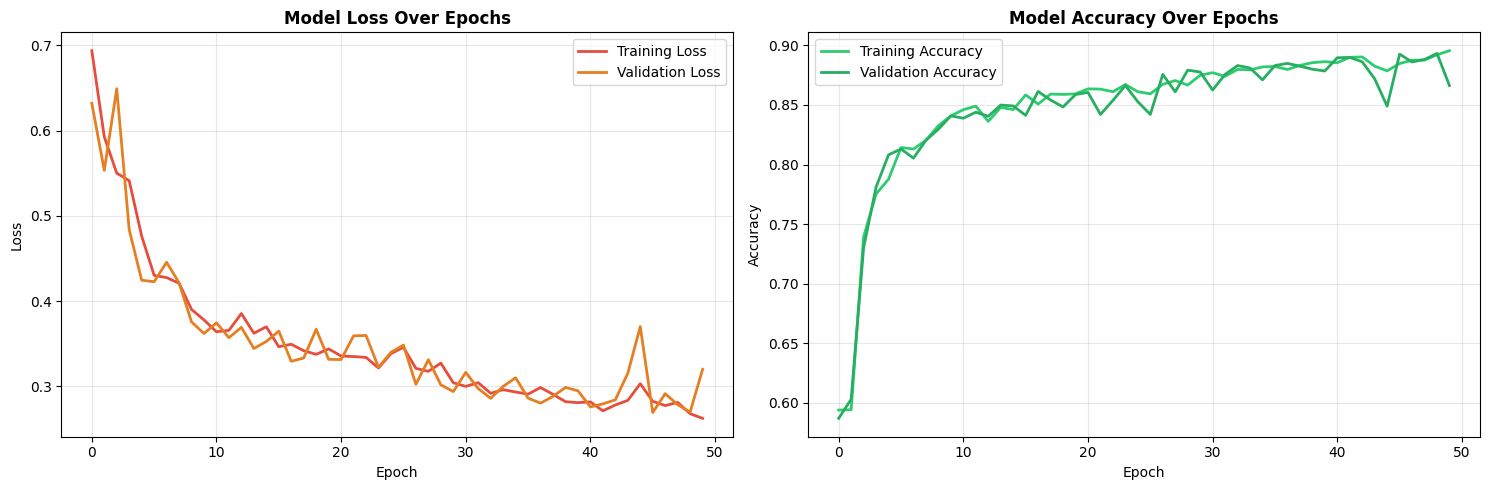


📊 Final Training Results:
   Training Loss: 0.2624 | Training Accuracy: 0.8956
   Validation Loss: 0.3199 | Validation Accuracy: 0.8663


In [14]:
# Train the CNN on actual flood detection data
print("🚀 Starting CNN training on flood detection data...")

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

print("✅ Training completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='#e74c3c', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e67e22', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', weight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#27ae60', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', weight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\n📊 Final Training Results:")
print(f"   Training Loss: {final_train_loss:.4f} | Training Accuracy: {final_train_acc:.4f}")
print(f"   Validation Loss: {final_val_loss:.4f} | Validation Accuracy: {final_val_acc:.4f}")

In [20]:
# Automatically serialize VISION model for the backend Flask/FastAPI routes requested
import os

# Define the models directory path from current working directory
models_dir = os.path.join("..", "models", "saved")
os.makedirs(models_dir, exist_ok=True)

cnn_model.save(os.path.join(models_dir, "cnn_model.h5"))
print(f"🛰️ Computer Vision Network securely compiled and exported physically to {os.path.abspath(models_dir)}!")

🛰️ Computer Vision Network securely compiled and exported physically to c:\Users\Admin\OneDrive\Desktop\PA\flood-ai-system\models\saved!
